<a href="https://colab.research.google.com/github/mrtchlpck/lecture1/blob/main/por%C3%B3wnanie_klasyfikator%C3%B3w.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Sprawdzenie wszystkich przypadków raka w danych

In [3]:
from sklearn.datasets import load_breast_cancer
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target

print("Liczba wszystkich przypadków:", X.shape[0])

Liczba wszystkich przypadków: 569


In [4]:
import pandas as pd

df = pd.DataFrame(X, columns=data.feature_names)
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


Ilość złośliwych i niezłośliwych odmian raka w danych

In [5]:
import numpy as np

malignant_cancer = np.sum(y == 1)
benign_cancer = np.sum(y == 0)

print("Liczba przypadków złośliwych:", malignant_cancer)
print("Liczba przypadków niezłośliwych:", benign_cancer)

Liczba przypadków złośliwych: 357
Liczba przypadków niezłośliwych: 212


Histogram średniego obszaru (mean area)

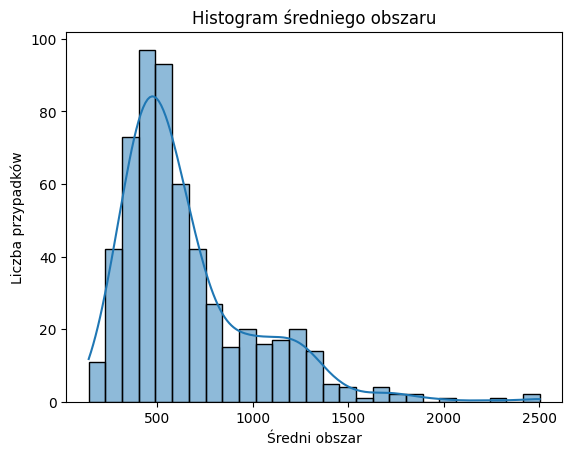

In [6]:
mean_area = X[:, data.feature_names.tolist().index("mean area")]

sns.histplot(mean_area, kde=True)
plt.title("Histogram średniego obszaru")
plt.xlabel("Średni obszar")
plt.ylabel("Liczba przypadków")
plt.show()

Wykres rozrzutu (scatterplot) średniego obszaru od klasyfikacji (użyj
sns.regplot)

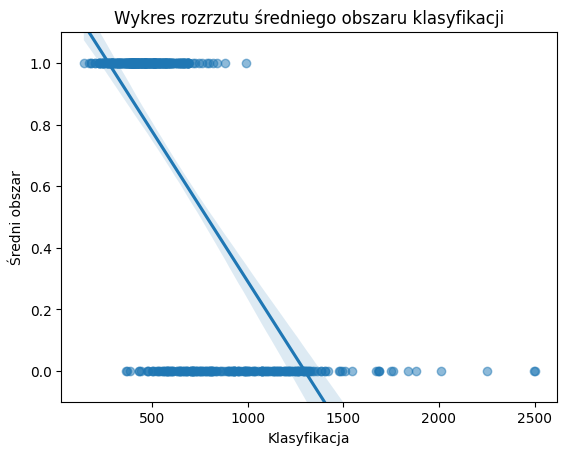

In [7]:
sns.regplot(x=mean_area, y=y, logistic=False, scatter_kws={"alpha": 0.5})
plt.title("Wykres rozrzutu średniego obszaru klasyfikacji")
plt.xlabel("Klasyfikacja")
plt.ylabel("Średni obszar")
plt.ylim(-0.1, 1.1)
plt.show()

Standaryzacja danych i import wszystkich potrzebnych bibliotek

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.metrics import RocCurveDisplay, roc_curve

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Podział danych na zbiór testowy (30%) i uczący (70%)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42)

Budowa modelu regresji logistycznej

In [10]:
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

LogisticRegression(max_iter=500)

Predykcja na zbiorze testowym

In [11]:
y_pred = model.predict(X_test)

Confusion Matrix

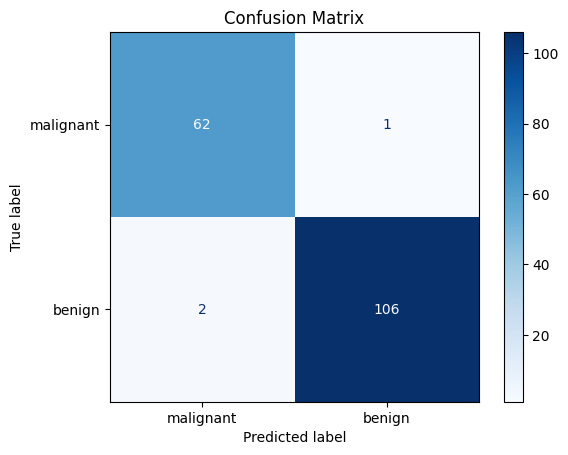

In [12]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

ROC

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_plot/roc_curve.py:189: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax_.legend(loc="lower right")


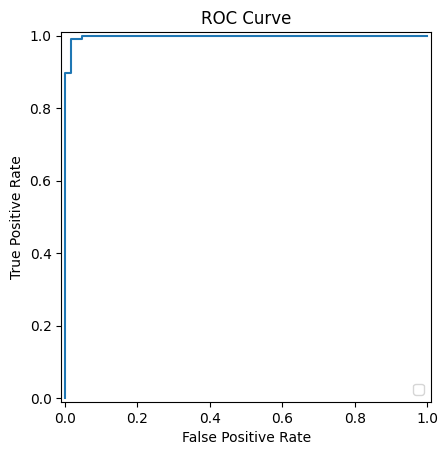

In [13]:
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr)
roc_disp.plot()
plt.title("ROC Curve")
plt.show()

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]
log_acc = accuracy_score(y_test, (y_prob > 0.5).astype(int))

print("Dokładność Logistic Regression:", log_acc)

Dokładność Logistic Regression: 0.9824561403508771


In [32]:
from sklearn.neighbors import KNeighborsClassifier

knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train, y_train)
knn5_acc = accuracy_score(y_test, knn5.predict(X_test))
print("Dokładność KNN (k=5):", knn5_acc)

knn7 = KNeighborsClassifier(n_neighbors=7)
knn7.fit(X_train, y_train)
knn7_acc = accuracy_score(y_test, knn7.predict(X_test))
print("Dokładność KNN (k=7):", knn7_acc)

Dokładność KNN (k=5): 0.9590643274853801
Dokładność KNN (k=7): 0.9649122807017544


In [34]:
from sklearn.metrics import pairwise_distances
import pandas as pd

x0 = X_test[0].reshape(1, -1)

distances = pairwise_distances(X_train, x0, metric='euclidean').flatten()

df = pd.DataFrame({
    "distance": distances,
    "class": y_train
})

df_sorted = df.sort_values(by="distance")

print("===== 5-NN =====")
display(df_sorted.head(5))

print("===== 7-NN =====")
display(df_sorted.head(7))

===== 5-NN =====


,distance,class
9,1.571236,1
283,1.681971,1
59,1.737246,1
240,2.075942,1
118,2.169195,1


===== 7-NN =====


,distance,class
9,1.571236,1
283,1.681971,1
59,1.737246,1
240,2.075942,1
118,2.169195,1
79,2.181994,1
112,2.199123,1


In [35]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred = nb.predict(X_test)
nb_acc = accuracy_score(y_test, y_pred)

print("Dokładność klasyfikatora Bayesowskiego:", nb_acc)

Dokładność klasyfikatora Bayesowskiego: 0.935672514619883


In [36]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

y_pred = tree.predict(X_test)
tree_acc = accuracy_score(y_test, y_pred)

print("Dokładność drzewa decyzyjnego:", tree_acc)

Dokładność drzewa decyzyjnego: 0.9415204678362573


In [37]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(n_estimators=15, random_state=42)
forest.fit(X_train, y_train)

y_pred = forest.predict(X_test)
forest_acc = accuracy_score(y_test, y_pred)

print("Dokładność lasu losowego (15 drzew):", forest_acc)

Dokładność lasu losowego (15 drzew): 0.9707602339181286


Wnioski:

*   Dane są dobrze separowalne.
*   Wyniki dla 5knn i 7knn są bardzo podobne co oznacza, że model jest stabilny.
*   Najbliźsi sąsiedzi należa do tej samej klasy co jest dobre.
*   Wieksza liczba sąsiadów to też większa odpornośc na szum.
*   Klasyfikator Bayesa zakłada niezależność cech a te dane są ze sobą skorelowane, co może być problematyczne.
*   Drzewo decyzyjne ma dobry wynik jednak często moga być przeuczone, dlatego las losowy jest lepszym modelem, ponieważ redukuje przeuczenie.
*   Las losowy jest też odporny na szum i korelacje między cechami.


Który model jest najlepszy?
* Najlepszym modelem jest las losowy ze względu na redukcję przeuczenia i najwyższą skuteczność.
* Las losowy nie potrzebuje skalowania i dobrze radzi sobie z szumem i cechami mniej istotnymi.

* Regresja liniowa to model liniowy, więc nie wychwytuje nieliniowych zależności.
* KNN jest wrazliwy na szum.
* Klasyfikator Baynesa zakłada niezależność cech, a tutaj cechy są zależne przy tym zbiorze danych.
* Drzewo decyzyjne można przeuczyć.

